# Analysis solubility trends

## Reviewer's comment

For solubility prediction, the manuscript largely relies on qualitative observations regarding "known trends" and "chemical intuition". A more systematic evaluation of the findings would be desirable. For example, this could be achieved by analyzing structure-property relationships in analog series and comparing the impact of specific R-groups to their predicted Shapley contribution. 
The same is true for comparison to other explainability methods: a definitive statement of performance like on page 11 line 42 ("Overall, the comparison shows that fragment-level Shapley values provide more coherent, chemically interpretable, and quantitatively meaningful attributions in this setting.") cannot be made without showing quantitative and systematic data.

In [102]:
import numpy as np
import pandas as pd

In [182]:
import sys
sys.path.append('../')
import FragShapley

from scipy.stats import pearsonr, spearmanr, kendalltau

In [104]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

def bemis_murcko_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold, isomericSmiles=False)

In [105]:
def canon(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=False)


def strip_brics_dummy_atoms(frag_smiles):
    mol = Chem.MolFromSmiles(frag_smiles)
    if mol is None:
        return None

    mol = Chem.DeleteSubstructs(mol, Chem.MolFromSmarts("[#0]"))
    Chem.SanitizeMol(mol)

    return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=False)


def get_bm_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold, canonical=True, isomericSmiles=False)


def get_bm_brics_index_default_order(smiles):
    bm = get_bm_scaffold(smiles)
    bm_can = canon(bm)

    brics_frags = FragShapley.utils.get_BRICS_fragments_as_SMILES(smiles, remove_dummies=False)

    for i, frag in enumerate(brics_frags):
        clean_frag = strip_brics_dummy_atoms(frag)

        if clean_frag == bm_can:
            return i

    return None

In [106]:
def split_bm_non_bm_attribution(row):
    bm_idx = row["bm_brics_index"]
    scores = row["fragExplainer_result"]

    if bm_idx is None:
        return None, sum(scores.values())

    bm_score = scores.get(bm_idx, 0.0)

    non_bm_score = sum(
        score for idx, score in scores.items()
        if idx != bm_idx
    )

    return bm_score, non_bm_score

In [107]:
def filter_atleast_n_attachment(smiles, n):
    if smiles.count('*') >= n:
        return True
    else:
        return False

In [108]:
def remove_isotope_info_from_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    for atom in mol.GetAtoms():
        atom.SetIsotope(0)

    return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=False)

def get_mean_contributions_wo_bm_scaffold(row, df_frag):
    bm_idx = int(row["bm_brics_index"])
    scores = row["fragExplainer_result"]
    fragments = row["brics_fragments"]

    if bm_idx is None:
        return None

    non_bm_indices = [idx for idx in scores.keys() if idx != bm_idx]

    non_bm_frags = [fragments[idx] for idx in non_bm_indices]

    mean_contribs = []
    for frag in non_bm_frags:
        ifrag = remove_isotope_info_from_smiles(frag)
        mean_contrib = df_frag.loc[df_frag['fragments'] == ifrag, 'mean']
        if not mean_contrib.empty:
            mean_contribs.append(mean_contrib.values[0])

    return mean_contribs

In [183]:
results = []

In [184]:
for model in ['rf','gcn']:
    df_expl = pd.read_pickle(f'../3_solubility/{model}_regression_solubility/df_explanation.pkl')

    df_expl["bm_scaffold"] = df_expl["smiles"].apply(bemis_murcko_scaffold)
    
    # Now we need to filter out the rows where we actually have more than one fragment
    df_expl_filtered = df_expl[df_expl["fragExplainer_result"].apply(lambda x: len(x) > 1)].copy()

    df = df_expl_filtered.copy()
    
    df["brics_fragments"] = df["smiles"].apply(lambda x: FragShapley.utils.get_BRICS_fragments_as_SMILES(x, remove_dummies=False))
    df["bm_scaffold"] = df["smiles"].apply(get_bm_scaffold)
    df["bm_brics_index"] = df["smiles"].apply(get_bm_brics_index_default_order)

    df[["bm_attribution", "non_bm_attribution"]] = df.apply(
        split_bm_non_bm_attribution,
        axis=1,
        result_type="expand"
    )

    df = df.dropna(subset='bm_brics_index')




    avg_contrib = pd.read_pickle(f'../3_solubility/{model}_regression_solubility/df_explanation.pkl')

    avg_contrib['fragments'] = avg_contrib.smiles.apply(lambda x: FragShapley.utils.get_BRICS_fragments_as_SMILES(x, remove_dummies=False))

    # get the values of the Explainer as a list (currently only available as dict)
    avg_contrib['fragExplainer_shapley_values'] = avg_contrib.fragExplainer_result.apply(lambda x: list(x.values()))
    # create a dataframe of all fragments (contains duplicates) and the corresponding Shapley Value
    df_frag = avg_contrib[['fragments', 'fragExplainer_shapley_values']].explode(['fragments', 'fragExplainer_shapley_values'], ignore_index=True)
    df_frag = df_frag.groupby('fragments').agg([len, 'mean', 'std']) # will throw warning because of error when calculating std for a single measurement
    df_frag = df_frag.reset_index() # reset so that 'fragments' is a column again and no longer the index
    df_frag.columns = [col[0] if col[1]=='' else col[1] for col in df_frag.columns.values] # rename, choose 'fragments' for first column, for the other simply len, mean, std

    df_frag = df_frag.loc[df_frag.fragments.apply(lambda x: filter_atleast_n_attachment(x, n=1))]

    df['non_bm_frag_mean_contribs'] = df.apply(lambda row: get_mean_contributions_wo_bm_scaffold(row, df_frag), axis=1)
    df['non_bm_frag_mean_contribs_sum'] = df['non_bm_frag_mean_contribs'].apply(sum)
    
    analogue_series = (
        df.groupby("bm_scaffold", dropna=False)
            .size()
            .reset_index(name="series_size")
            .sort_values("series_size", ascending=False)
    )

    scaffolds_of_interest = analogue_series[analogue_series["series_size"] >= 5]["bm_scaffold"].tolist()

    df = df[df.bm_scaffold.isin(scaffolds_of_interest)].copy()

    for bm in df.bm_scaffold.unique():
        subset = df[df.bm_scaffold == bm]
        print(f"BM Scaffold: {bm}")
        stat = pearsonr(subset['non_bm_frag_mean_contribs_sum'], subset['y_pred'])
        stat_kendall = kendalltau(subset['non_bm_frag_mean_contribs_sum'], subset['y_pred'])
        results.append({'model': model,
                        'bm_scaffold': bm,
                        'pearson_r': stat.statistic,
                        'pearson_pvalue': stat.pvalue,
                        'kendall_tau': stat_kendall.statistic,
                        'kendall_pvalue': stat_kendall.pvalue,
                        'size': int(len(subset)),
                        'values_sum': subset['non_bm_frag_mean_contribs_sum'].tolist(),
                        'y_pred': subset['y_pred'].tolist()
                        })

BM Scaffold: c1ccccc1
BM Scaffold: O=C1CC(=O)NC(=O)N1
BM Scaffold: c1ncncn1
BM Scaffold: c1ccccc1
BM Scaffold: O=C1CC(=O)NC(=O)N1
BM Scaffold: c1ncncn1


In [185]:
out = pd.DataFrame(results)

In [186]:
print(out)

  model         bm_scaffold  pearson_r  pearson_pvalue  kendall_tau  \
0    rf            c1ccccc1   0.787878    3.541291e-13     0.556740   
1    rf  O=C1CC(=O)NC(=O)N1   0.517884    4.799028e-02     0.428571   
2    rf            c1ncncn1   0.356911    3.457340e-01     0.333333   
3   gcn            c1ccccc1   0.871175    1.245731e-18     0.658728   
4   gcn  O=C1CC(=O)NC(=O)N1   0.619730    1.373234e-02     0.809524   
5   gcn            c1ncncn1   0.259482    5.001558e-01     0.277778   

   kendall_pvalue  size                                         values_sum  \
0    9.768504e-10    57  [0.3534087500000008, 0.22877193847332203, 0.31...   
1    2.749527e-02    15  [-0.46092338161375696, -1.459067118726299, -0....   
2    2.595183e-01     9  [-0.5282072261347727, -0.7599892223136758, -0....   
3    4.651977e-13    57  [1.3117031455039978, 1.3380130631096923, 1.510...   
4    2.274667e-06    15  [-0.906361914343304, -2.820974333239044, -2.58...   
5    3.584877e-01     9  [0.634701

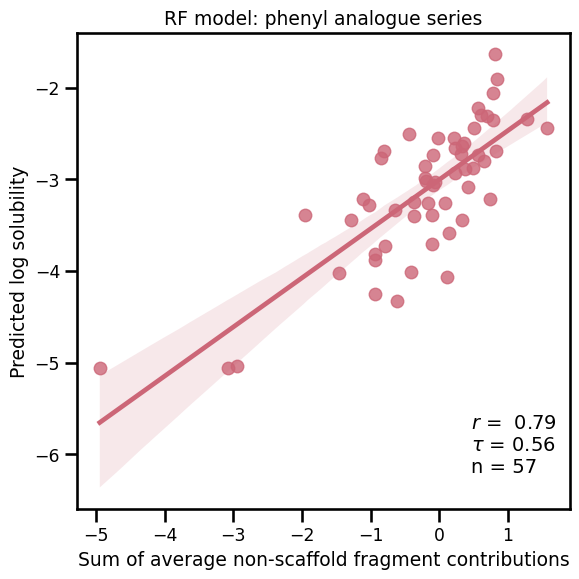

In [195]:
# figure for phenyl core with correlation

model = 'rf'
scaffold = 'c1ccccc1'
scaffold_name = 'phenyl'

subset = out[(out['model'] == model) & (out['bm_scaffold'] == scaffold)]

import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('style.mplstyle')
sns.set_context('talk', font_scale=0.75)
fig_folder = os.path.abspath("figures/final_figures")

fig, axs = plt.subplots(1, 1, figsize=(6, 6))

sns.regplot(x=subset['values_sum'].iloc[0], y=subset['y_pred'].iloc[0],
            ax=axs)

axs.set_xlabel('Sum of average non-scaffold fragment contributions')
axs.set_ylabel('Predicted log solubility')
axs.set_title(f'{model.upper()} model: {scaffold_name} analogue series')

axs.text(
    s=f"$r$ =  {subset['pearson_r'].iloc[0]:.2f}\n"
      f"$\\tau$ = {subset['kendall_tau'].iloc[0]:.2f}\n"
      f"n = {subset['size'].iloc[0]:}",
    x=0.8,
    y=0.2,
    transform=axs.transAxes,
    ha='left',
    va='top',
    fontsize=14,
)
fig.tight_layout()

fig.savefig(os.path.join(fig_folder, f'S_solubility_AS_{model}_{scaffold_name}.pdf'), 
            bbox_inches='tight',
            )

to manuscript:

To quantitatively evaluate whether fragment-level Shapley values capture substituent effects, Bemis–Murcko analogue series were extracted from the aqueous solubility dataset. For the largest analogue series (phenyl scaffold, n=57), the sum of average non-scaffold fragment Shapley values correlated strongly with the model predictions (Pearson r=0.79, Kendall τ=... for RF; Pearson r=0.87, Kendall τ=... for GCN). These results indicate that average fragment contributions capture a substantial fraction of substituent-driven variation within related chemical series.

To reviewer:

We thank the reviewer for this suggestion. To provide a more systematic evaluation, we performed an analogue-series analysis based on Bemis–Murcko scaffolds. For each analogue series, the sum of average non-scaffold fragment Shapley values was compared with the model prediction. Strong correlations were observed for the largest analogue series (phenyl scaffold; n=57), with Pearson correlations of 0.79 (RF) and 0.87 (GCN). These results quantitatively support the hypothesis that fragment-level Shapley values capture meaningful substituent effects beyond qualitative chemical intuition.

Caption:

Relationship between predicted log solubility and the sum of average non-scaffold fragment Shapley values for compounds belonging to the phenyl analogue series (n = 57). Average fragment contributions were computed across all molecules in the dataset and summed for the substituents of each compound. The strong correlation indicates that fragment-level Shapley values capture substituent-driven variation within a common scaffold series.

I would still slightly soften the conclusion sentence in the SHAP/GNNExplainer comparison section.

Instead of:

"Overall, the comparison shows that fragment-level Shapley values provide more coherent, chemically interpretable, and quantitatively meaningful attributions in this setting."

I would write:

"Overall, the comparison suggests that fragment-level Shapley values provide more coherent and chemically interpretable attributions in this setting."

or

"Overall, fragment-level Shapley values yield attributions that are more readily interpretable in terms of chemically meaningful substructures."

This removes the strongest claim that the reviewer objected to while leaving your argument intact.